# HOMEWORK 13

In this homework you are going to build your first classifier for the CIFAR-10 dataset. This dataset contains 10 different classes and you can learn more about it [here](https://www.cs.toronto.edu/~kriz/cifar.html). This homework consists of the following tasks:
* Dataset inspection
* Building the network
* Training
* Evaluation

At the end, as usual, there will be a couple of questions for you to answer :-)

In [22]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Step 0: Dataset Inspection

Load the dataset and make a quick inspection.

C:\Users\Dmytro Dubrovsky\AppData\Local\Temp\ipykernel_20048\223916333.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(classes[int(y_train[idx])])


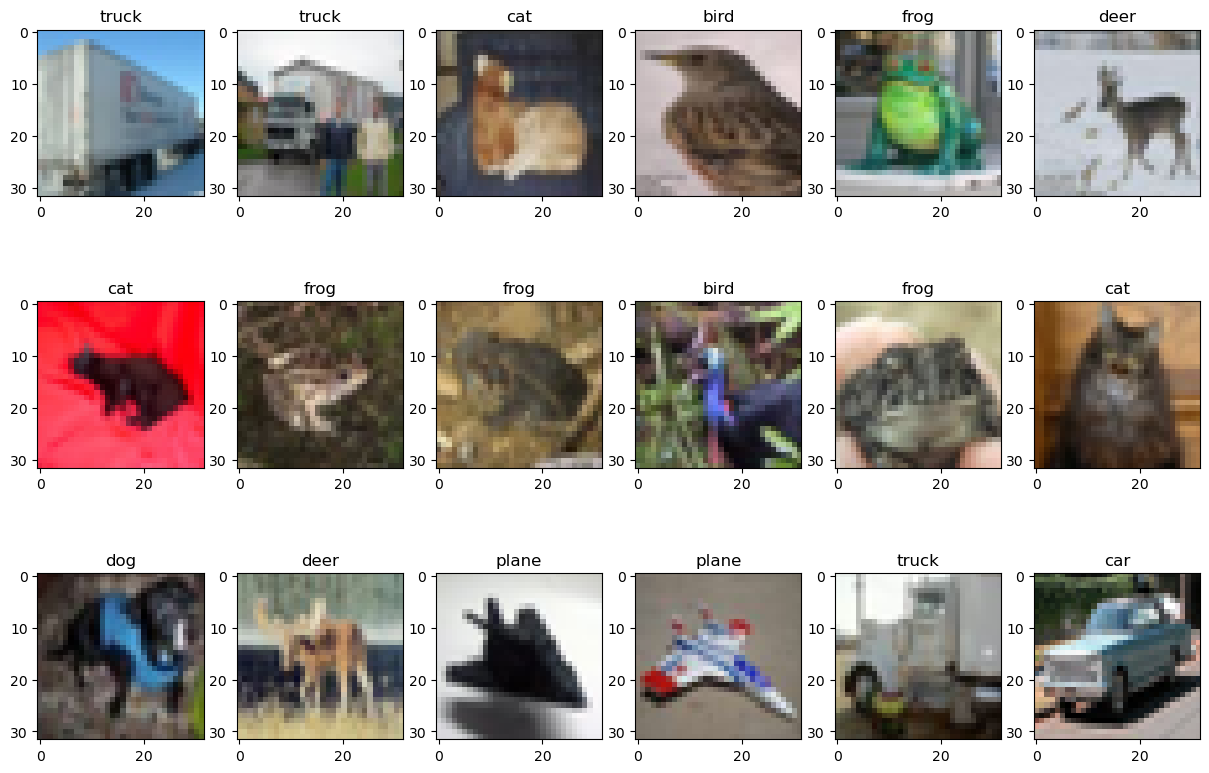

In [23]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):    
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    idx = ii+15
    # Show the image and the label
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx])])

Compute the class histogram (you can visualize it if you want). Is the dataset balanced?

Hint: You might find [Counter](https://docs.python.org/3/library/collections.html#collections.Counter) tool useful. In any case, it's up to you how you compute the histogram.

(Text(0.5, 0, 'Class ID'), Text(0, 0.5, 'Counts'))

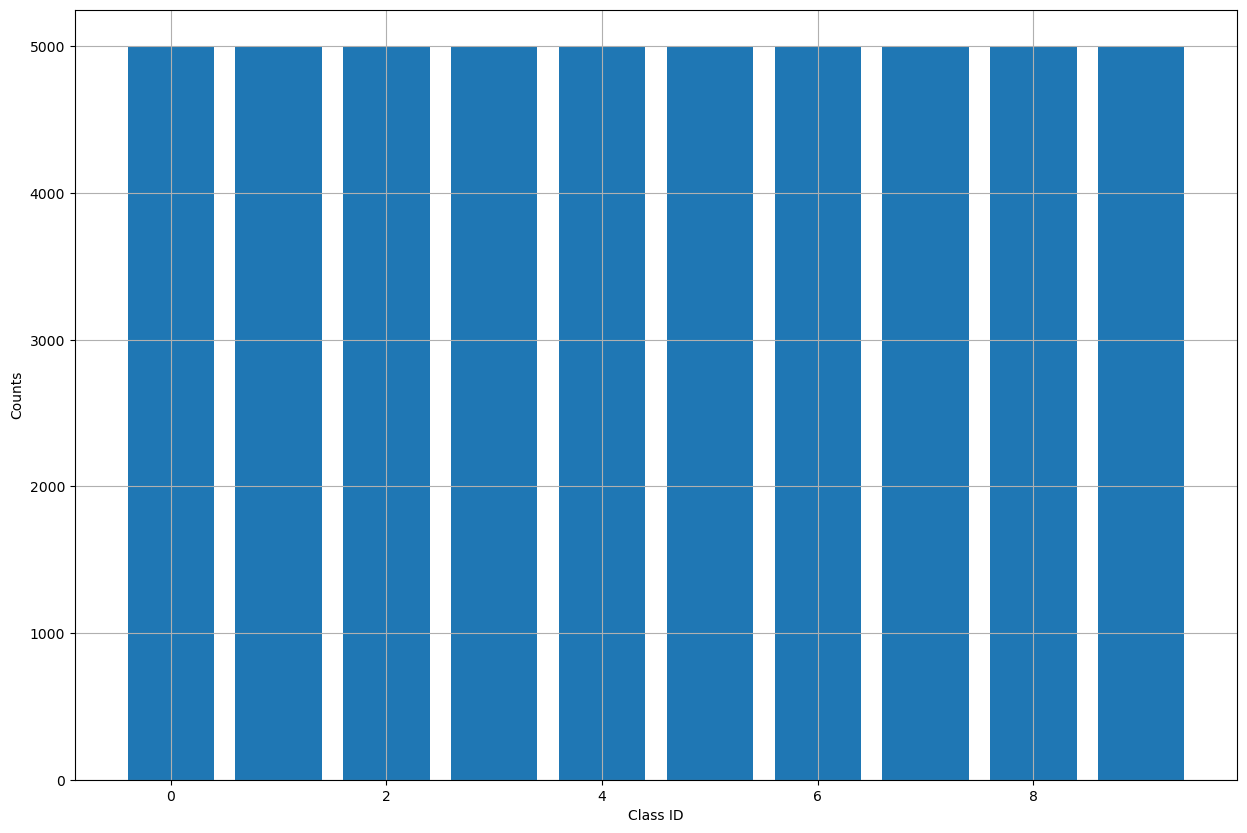

In [24]:
# Compute the class histogram
from collections import Counter
hist = Counter(y_train.flatten())

plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Class ID'), plt.ylabel('Counts')


### So CIFAR-10 is balanced — each class has 5,000 images.

### Step 1: Data Preparation

In this step, you'll need to prepare the data for training, i.e., you will have to normalize it and encode the labels as one-hot vectors.

In [25]:
# Normalization 
# Convert pixel values (0–255) to floats between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# --- One-hot encoding ---
# Convert class indices (0–9) to one-hot vectors
y_train = to_categorical(y_train, num_classes)
y_test  = to_categorical(y_test, num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


### Step 2: Building the Classifier

Build the CNN for CIFAR10 classification. For starters, you can use the same network we used in the lesson for the MNIST problem.

In [26]:
inputs = Input(shape=(size, size, 3))

net = Conv2D(32, kernel_size=(3, 3), activation="relu")(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(32, kernel_size=(3, 3), activation="relu")(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Flatten()(net)
outputs = Dense(num_classes, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 13, 13, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │          11,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,674 (84.66 KB)

 Trainable params: 21,674 (84.66 KB)

 Non-trainable params: 0 (0.00 B)

### Step 3: Training

Compile the model and train it.

In [27]:
epochs = 25
batch_size = 128

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

start = time()
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
print('Elapsed time', time() - start)


Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.3886 - loss: 1.7102 - val_accuracy: 0.4450 - val_loss: 1.5726
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5122 - loss: 1.3818 - val_accuracy: 0.5072 - val_loss: 1.4087
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5524 - loss: 1.2778 - val_accuracy: 0.5436 - val_loss: 1.2809
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5799 - loss: 1.2069 - val_accuracy: 0.5738 - val_loss: 1.2014
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5986 - loss: 1.1503 - val_accuracy: 0.6028 - val_loss: 1.1379
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6145 - loss: 1.1041 - val_accuracy: 0.6140 - val_loss: 1.0986
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6290 - loss: 1.0653 - val_accuracy: 0.6246 - val_loss: 1.0683
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6417 - loss: 1.0336 - val_accu

Train Acc      0.7305777668952942
Validation Acc 0.6958000063896179


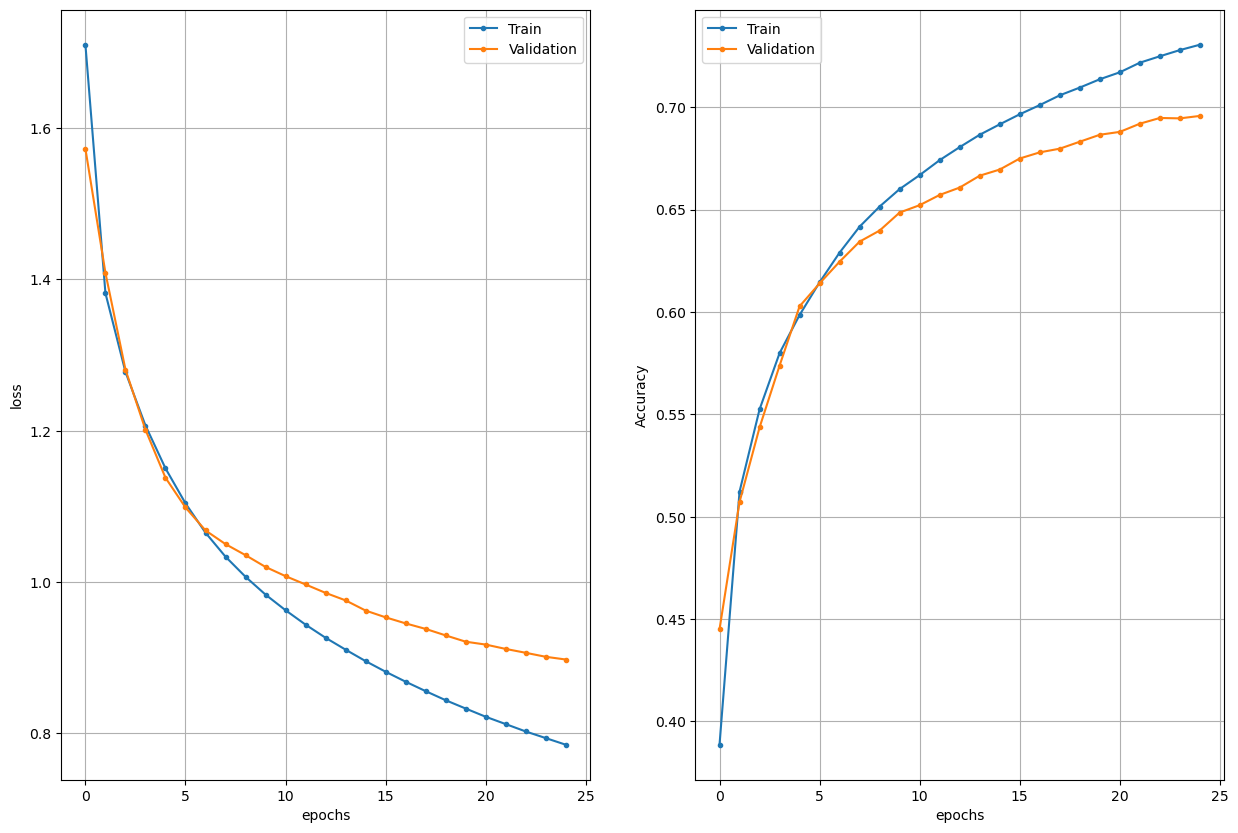

In [28]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])    

### Step 4: Evaluation

In this step, you have to calculate the accuracies and visualize some random samples. For the evaluation, you are going to use the test split from the dataset.

In [30]:
# Compute the labels and the predictions as sparse values
#True labels
y_true = np.argmax(y_test, axis=1) 
#Predicted labels
y_pred = np.argmax(model.predict(x_test), axis=1)
print(y_true)
print(y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[3 8 8 ... 5 1 7]
[3 8 8 ... 5 4 7]


In [31]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():
    
    # Boolean mask for samples of this class
    mask = (y_true == class_id)
    
    # Compute accuracy for this class
    acc = np.sum(y_pred[mask] == y_true[mask]) / np.sum(mask)
    
    print(f"{class_name}: {acc:.4f}")

plane: 0.7170
car: 0.7840
bird: 0.5610
cat: 0.3750
deer: 0.7550
dog: 0.6370
frog: 0.7910
horse: 0.7140
ship: 0.7320
truck: 0.7920


In [32]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6858 - loss: 0.9277
Test loss   0.9276950359344482
Test metric 0.6858000159263611


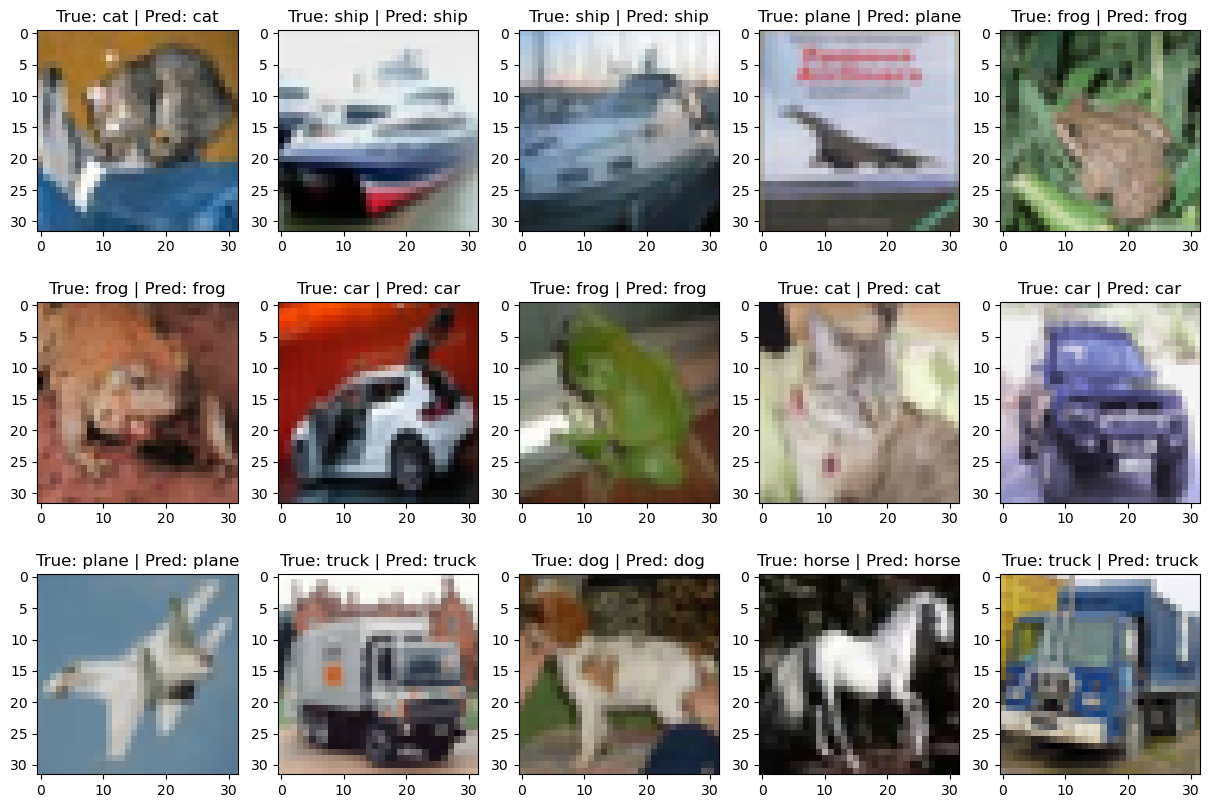

In [33]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = ii
    # Show the results
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))

### Questions
* What is the overall accuracy of the classifier?

### Answers
  
*  Overall accuracy of our CNN is near 0.7 (to be honest, I expected it would be more accurate)
*  I did some changes - first of all I added more Convolutional Layers, also I added a Dropout (a regularization technique used in neural networks to prevent overfitting).

### Conclusion
  
  I've got overall accuracy of the new CNN  near 0.8 (a little bit higher). However education time was much longer than for the first CNN.

### ALL calculations are below

  


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # Convolutional block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Convolutional block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Fully connected block
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=2
)

Epoch 1/20
782/782 - 39s - 50ms/step - accuracy: 0.4055 - loss: 1.6163 - val_accuracy: 0.5727 - val_loss: 1.1955
Epoch 2/20
782/782 - 40s - 51ms/step - accuracy: 0.5897 - loss: 1.1547 - val_accuracy: 0.6501 - val_loss: 0.9852
Epoch 3/20
782/782 - 50s - 64ms/step - accuracy: 0.6536 - loss: 0.9790 - val_accuracy: 0.7051 - val_loss: 0.8463
Epoch 4/20
782/782 - 54s - 69ms/step - accuracy: 0.6903 - loss: 0.8750 - val_accuracy: 0.7165 - val_loss: 0.8197
Epoch 5/20
782/782 - 57s - 73ms/step - accuracy: 0.7217 - loss: 0.7945 - val_accuracy: 0.7349 - val_loss: 0.7684
Epoch 6/20
782/782 - 72s - 93ms/step - accuracy: 0.7367 - loss: 0.7422 - val_accuracy: 0.7330 - val_loss: 0.7835
Epoch 7/20
782/782 - 67s - 86ms/step - accuracy: 0.7566 - loss: 0.6903 - val_accuracy: 0.7459 - val_loss: 0.7537
Epoch 8/20
782/782 - 69s - 88ms/step - accuracy: 0.7703 - loss: 0.6542 - val_accuracy: 0.7581 - val_loss: 0.7180
Epoch 9/20
782/782 - 65s - 83ms/step - accuracy: 0.7814 - loss: 0.6181 - val_accuracy: 0.7626 - 

Train Acc      0.8550800085067749
Validation Acc 0.788100004196167


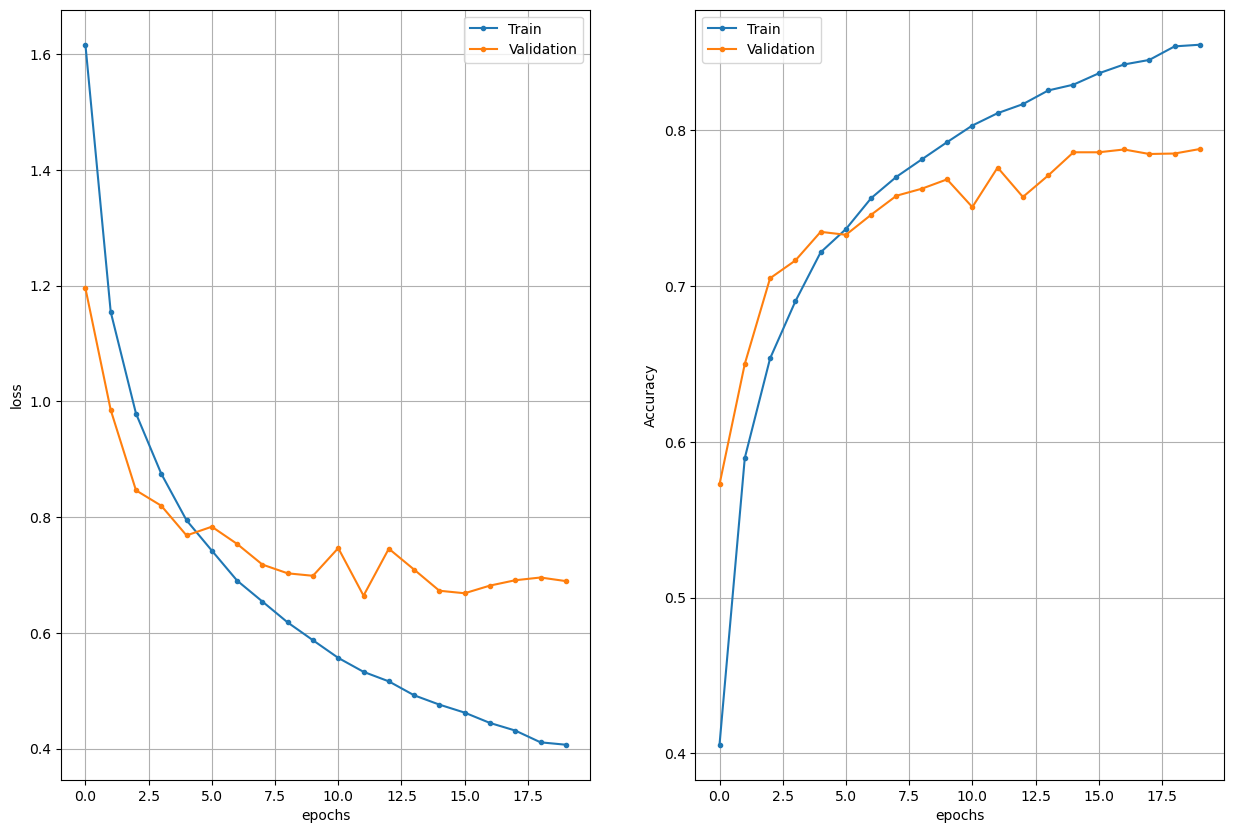

In [37]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])  

In [38]:
# Compute the labels and the predictions as sparse values
#True labels
y_true = np.argmax(y_test, axis=1) 
#Predicted labels
y_pred = np.argmax(model.predict(x_test), axis=1)
print(y_true)
print(y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
[3 8 8 ... 5 1 7]
[3 8 1 ... 5 1 7]


In [39]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():
    
    # Boolean mask for samples of this class
    mask = (y_true == class_id)
    
    # Compute accuracy for this class
    acc = np.sum(y_pred[mask] == y_true[mask]) / np.sum(mask)
    
    print(f"{class_name}: {acc:.4f}")

plane: 0.8610
car: 0.9150
bird: 0.6500
cat: 0.5190
deer: 0.7170
dog: 0.7660
frog: 0.8710
horse: 0.8590
ship: 0.8510
truck: 0.8720


In [40]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7881 - loss: 0.6895
Test loss   0.6895087361335754
Test metric 0.788100004196167


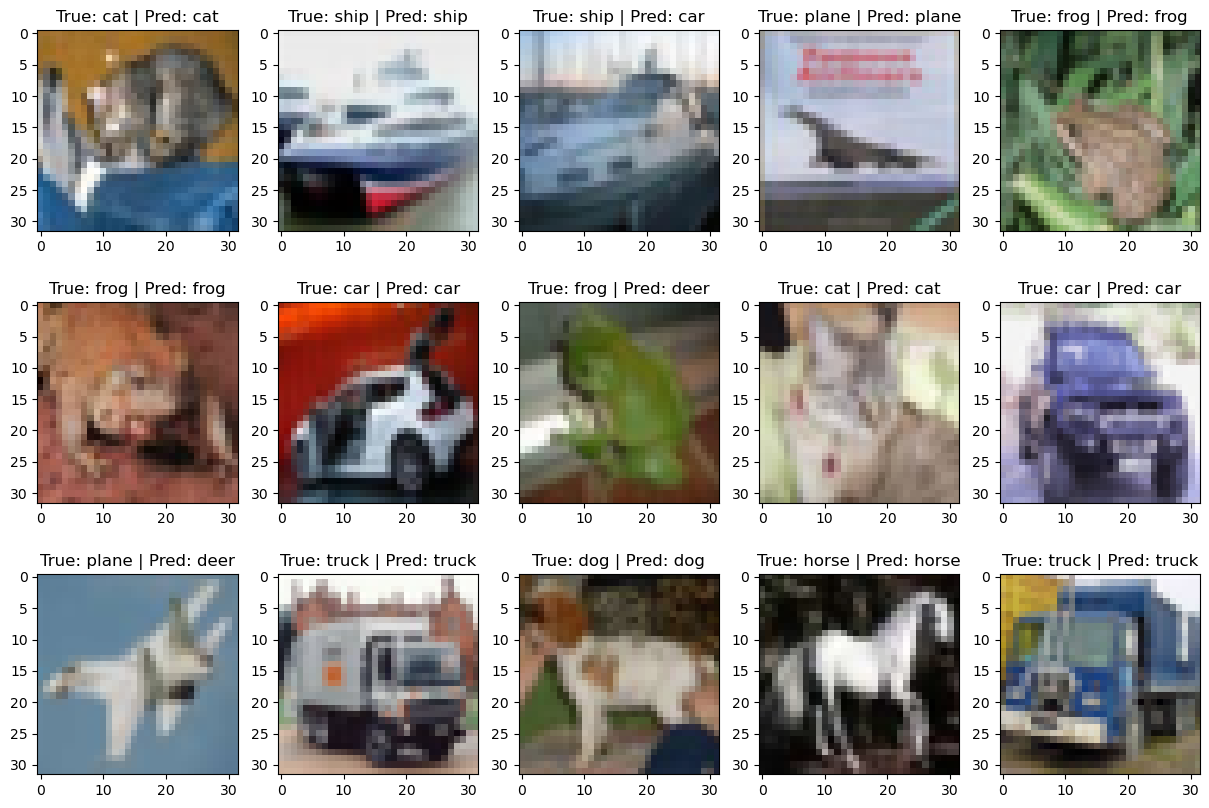

In [41]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = ii
    # Show the results
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))